# Dataset creation: από raw CSVs σε MongoDB

## Πού βρισκόμαστε στον AIoT lifecycle
Σύμφωνα με το 8-step ML project checklist, αυτό το notebook υλοποιεί το **Βήμα 2 - Get the Data**: συλλογή, ανωνυμοποίηση, μετατροπή σε format που χειρίζεται εύκολα, και αποθήκευση σε ένα queryable storage layer. Είναι το πρώτο στάδιο ολόκληρης της αλυσίδας pattern recognition.

## Τι κάνει το notebook
End-to-end ingestion pipeline:
1. **Discovery + Pairing**: εντοπίζει τα raw `acc` και `gyr` CSVs κάτω από το `data/` και τα ζευγαρώνει ανά session με βάση το κοινό session key.
2. **Visualization**: παράγει static 6-axis time-series plots και 3D acc / gyr scatter ανά session κάτω από το `outputs/figures/` ως πρώτο sanity check πριν από οποιοδήποτε processing.
3. **Merge + Filter**: κάνει join τα δύο streams στο `Epoch` με tolerance 10 ms και εφαρμόζει zero-phase Butterworth lowpass.
4. **Persist**: εισάγει ένα ενιαίο 6-axis document ανά session στη MongoDB collection που ορίζεται από το `config.yml`.

Όλη η βαριά λογική ζει στα `utils.py` και `utils_visual.py`. Το notebook λειτουργεί ως orchestration layer.

## Sampling parameters
Παράμετροι που πρέπει να καταγράφονται την ώρα της συλλογής, ποτέ default-assumed:

| Parameter | Why it matters |
|---|---|
| Sampling rate (Hz) | Nyquist bound, windowing, filter design |
| Sensor range (`±g`, `±dps`) | Saturation detection, normalisation |
| Sensor placement | Axis orientation conventions |
| Firmware version | Η calibration μπορεί να αλλάζει silently |
| Timestamp source | System clock vs sensor clock drift |

Στο dataset μας: MetaMotionR IMU, `fs = 100 Hz`, accelerometer range `±8 g`, gyroscope range `±2000 dps`. Τα timestamps έρχονται από την onboard clock του αισθητήρα (Epoch ms).

## Prerequisite
Η instance της MongoDB πρέπει να τρέχει τοπικά (`mongod` service up):
- macOS: `brew services start mongodb-community`
- Windows: `net start MongoDB`
- Linux: εκκίνηση του service και επικοινωνία μέσω `mongosh`


## Setup

Imports και configuration. Όλες οι παράμετροι παραμένουν στο `config.yml` ώστε οι επιλογές data transformation να αντιμετωπίζονται ως **hyperparameters**. Έτσι το rerun με διαφορετικές τιμές γίνεται εύκολο, χωρίς αλλαγές στο notebook.


In [1]:
import os
from pathlib import Path
from collections import Counter

import yaml
from pathlib import Path

from utils import (
    discover_csvs, pair_acc_gyr, build_document,
    load_acc_csv, load_gyr_csv, merge_acc_gyr, apply_continuous_filter,
    mongo_connect, insert_documents
)
from utils_visual import load_data_for_visualization, Plot_3axis, Plot_6axis

## Load configuration

Φόρτωση του `config.yml` που περιέχει:
- Database connection (`client`, `db`, `col`).
- Path settings (`data_path`, `out_figures`, `out_cache`).
- Παραμέτρους sliding window και filter που θα χρησιμοποιηθούν downstream.
- `reset_collection: true` για idempotent re-runs (καθαρίζει την collection πριν την εισαγωγή).

Η αρχή είναι: *"Work on copies of the data, keep the original dataset intact"*. Τα raw CSVs δεν τροποποιούνται· όλες οι παράγωγες αναπαραστάσεις αποθηκεύονται σε ξεχωριστές τοποθεσίες.


In [2]:
BASE_DIR = Path(os.getcwd()).resolve()

config_path = BASE_DIR / "config.yml"
with open(config_path, encoding='utf-8') as f:
    config = yaml.safe_load(f)
DATA_DIR = (BASE_DIR / config["data_path"]).resolve()
FIGURES_DIR = (BASE_DIR / config["out_figures"]).resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FILTER_ORDER = config["filter"]["order"]
FILTER_WN = config["filter"]["wn"]
FILTER_TYPE = config["filter"]["type"]

print("data:    ", DATA_DIR)
print("figures: ", FIGURES_DIR)
print(f"filter:   Butterworth {FILTER_TYPE} order={FILTER_ORDER} wn={FILTER_WN}")

data:     /home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/data
figures:  /home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/outputs/figures
filter:   Butterworth lowpass order=4 wn=0.2


## 1. Discover + Pair raw CSVs

Κάθε session έχει **δύο** raw CSVs (`acc` και `gyr` ξεχωριστά). Ζευγαρώνονται με βάση το κοινό session key:

```
session_key = (gesture_id, finger, typing_style, hand, primary, user)
```

Το μοναδικό πεδίο που διαφέρει είναι το `sensor`. Η `pair_acc_gyr` διαχωρίζει τα CSVs με την `parse_filename` και επιστρέφει triples `(shared_meta, acc_path, gyr_path)`.

Συνολικά εντοπίζονται **54 CSV files** και παράγονται **27 paired sessions** = 9 (gesture × variant) συνδυασμοί × 3 users.

## Γιατί ξεχωριστά CSVs
Ο αισθητήρας MetaMotionR στέλνει τα accelerometer και gyroscope streams σε ξεχωριστά κανάλια BLE, καθένα με δική του buffer rate και timestamp clock. Η συγχώνευση γίνεται σε δεύτερο στάδιο (cell 9) με tolerance-based join, όχι με row-level join. Αυτή η αρχιτεκτονική αποφεύγει drops όταν τα δύο streams δεν είναι ακριβώς συγχρονισμένα.


In [3]:
csvs = discover_csvs(DATA_DIR)
print(f"Found {len(csvs)} CSV files")

pairs = list(pair_acc_gyr(csvs))
print(f"Paired {len(pairs)} sessions (expecting 27 = 9 gesture×variant × 3 users)")

# Quick sanity: balance per (gesture, user)
Counter((m["gesture_id"], m["user"]) for m, _, _ in pairs)

Found 54 CSV files
Paired 27 sessions (expecting 27 = 9 gesture×variant × 3 users)


Counter({('scroll-down', 'a'): 2,
         ('scroll-down', 'b'): 2,
         ('scroll-down', 's'): 2,
         ('scroll-up', 'a'): 2,
         ('scroll-up', 'b'): 2,
         ('scroll-up', 's'): 2,
         ('swipe-left', 'a'): 2,
         ('swipe-left', 'b'): 2,
         ('swipe-left', 's'): 2,
         ('swipe-right', 'a'): 2,
         ('swipe-right', 'b'): 2,
         ('swipe-right', 's'): 2,
         ('texting', 'a'): 1,
         ('texting', 'b'): 1,
         ('texting', 's'): 1})

## 2. Visualize Data from Wearable

Pre-cleaning visual sanity check. Παράγουμε για κάθε χειρονομία (thumb και index variant) τα 6-axis time-series plots και 3D acc / gyr scatter, στα **πρώτα 128 samples των raw unfiltered δεδομένων**. Στόχοι:
- επαλήθευση ότι όλα τα channels μεταδίδουν δεδομένα (όχι flatline / NaN gaps),
- εντοπισμός εμφανών data quality issues (saturation, dropouts, spikes) πριν από οποιοδήποτε processing,
- σύγκριση της μορφής των χειρονομιών μεταξύ subjects σε raw επίπεδο.

Αυτό ευθυγραμμίζεται με το **Βήμα 5 (Visualize the data)** και το **Βήμα 7 (Study how you would solve the problem manually)** του checklist: πριν δώσουμε signals σε ένα μοντέλο, καταλαβαίνουμε πώς μοιάζουν στο μάτι.

## Common data quality issues
| Issue | Συμπτώματα | Action |
|---|---|---|
| Missing samples / NaN gaps | Bluetooth drops, OS preemption | Interpolate gaps `< 0.5s`, discard longer |
| Duplicate timestamps | Logging bugs | Drop duplicates, keep first |
| Sensor saturation / clipping | Τιμές που κολλούν στο `±max` range | Flag and exclude affected windows |
| Spurious outlier spikes | Electrostatic discharge, mechanical shock | Detect via z-score / IQR, interpolate |
| Sensor drift / DC offset | Slow baseline wander | Detrend πριν από filtering |

Στο pipeline μας, οι πολιτικές gap-filling και outlier υλοποιούνται downstream στο segmentation notebook (cells 5 και 9 εκεί).


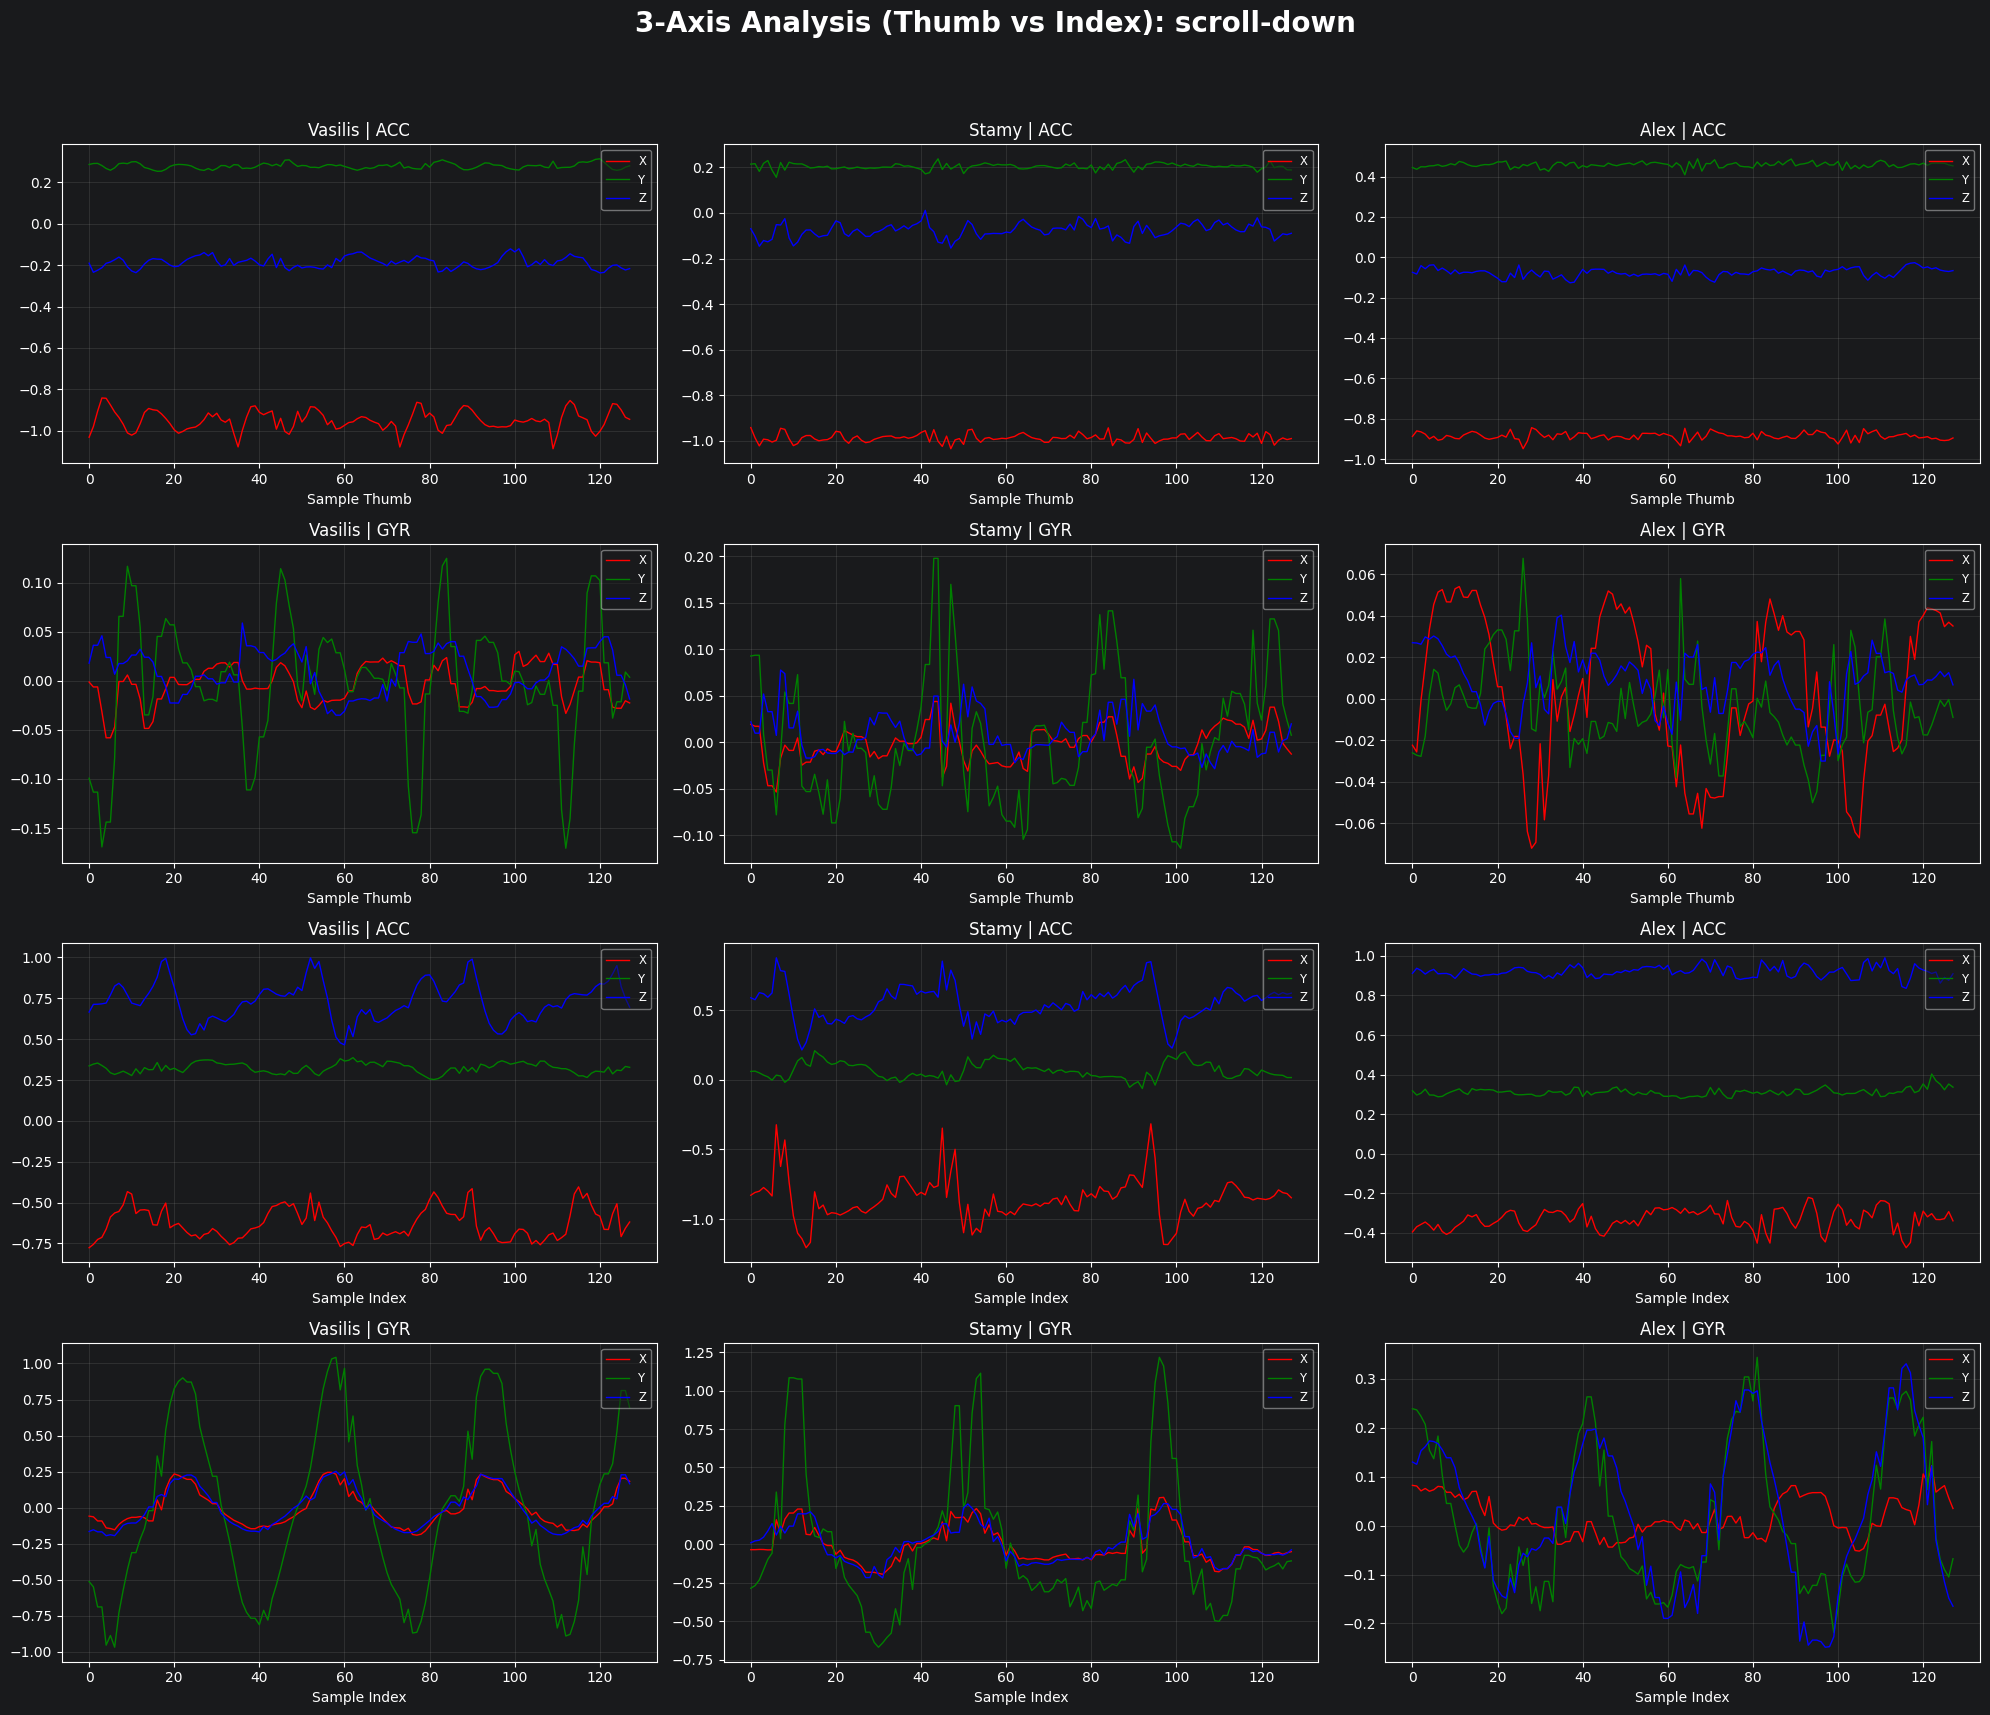

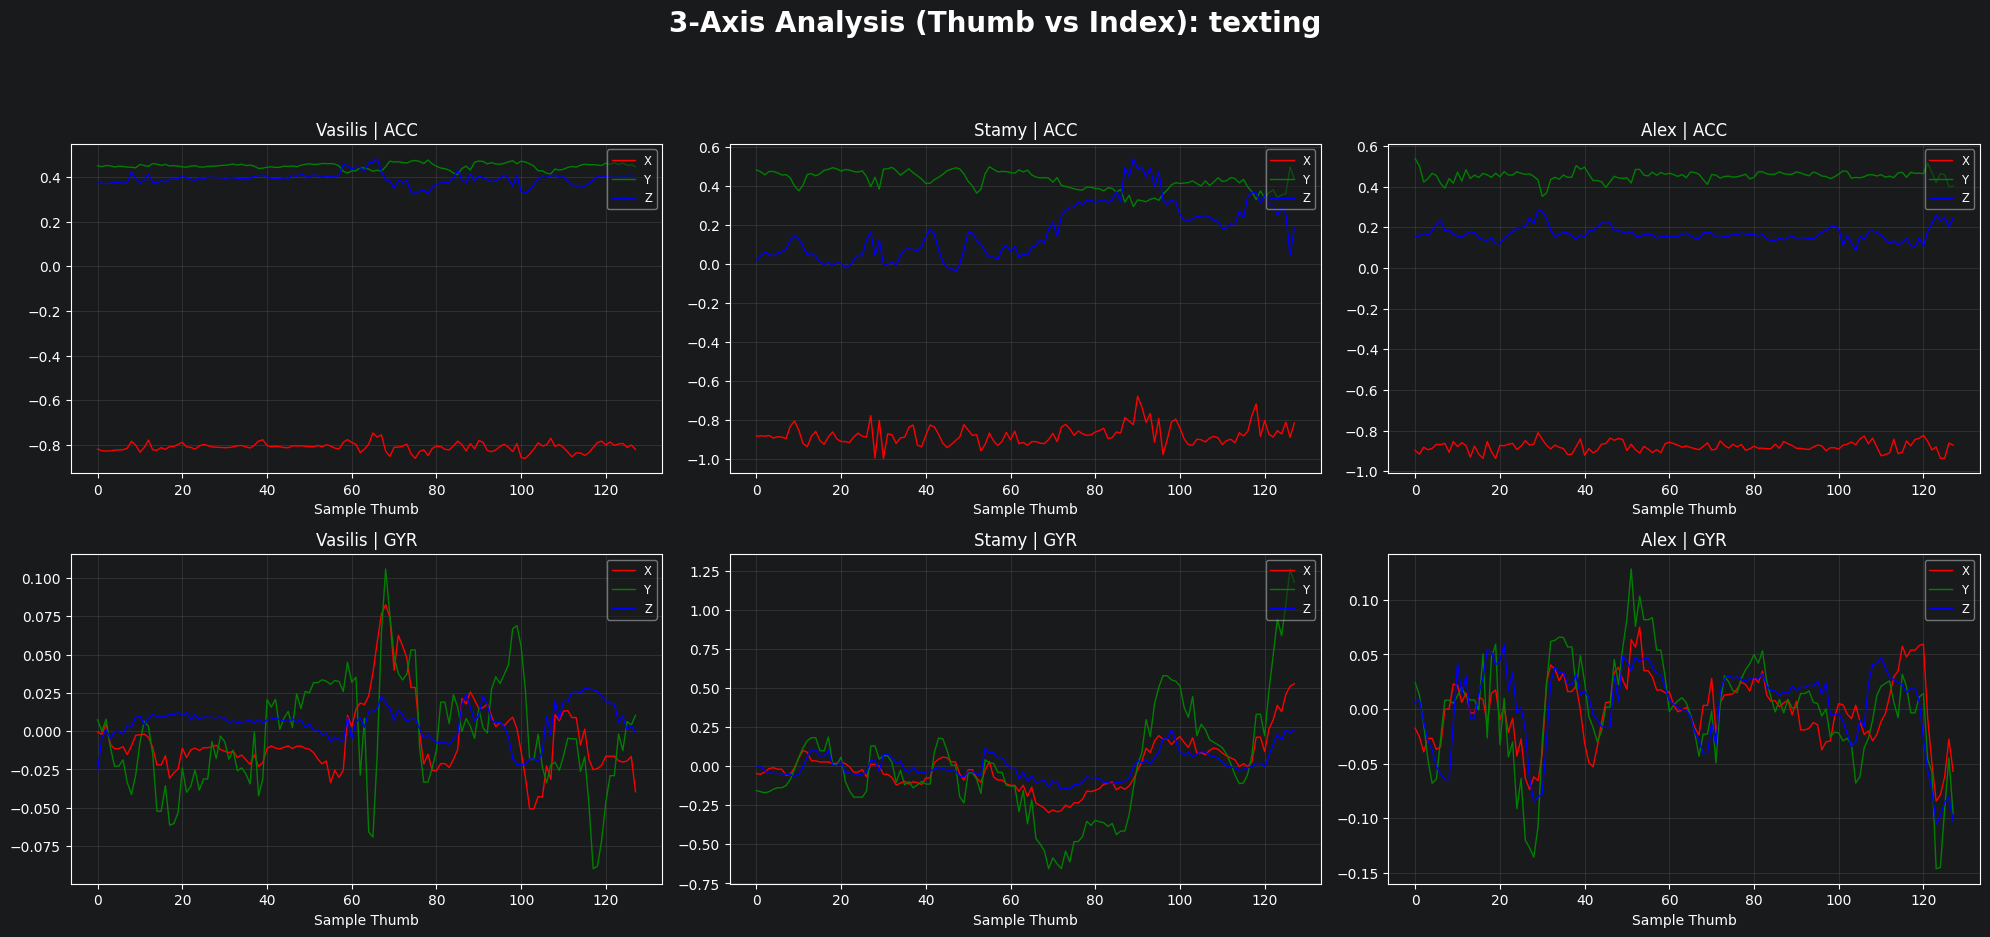

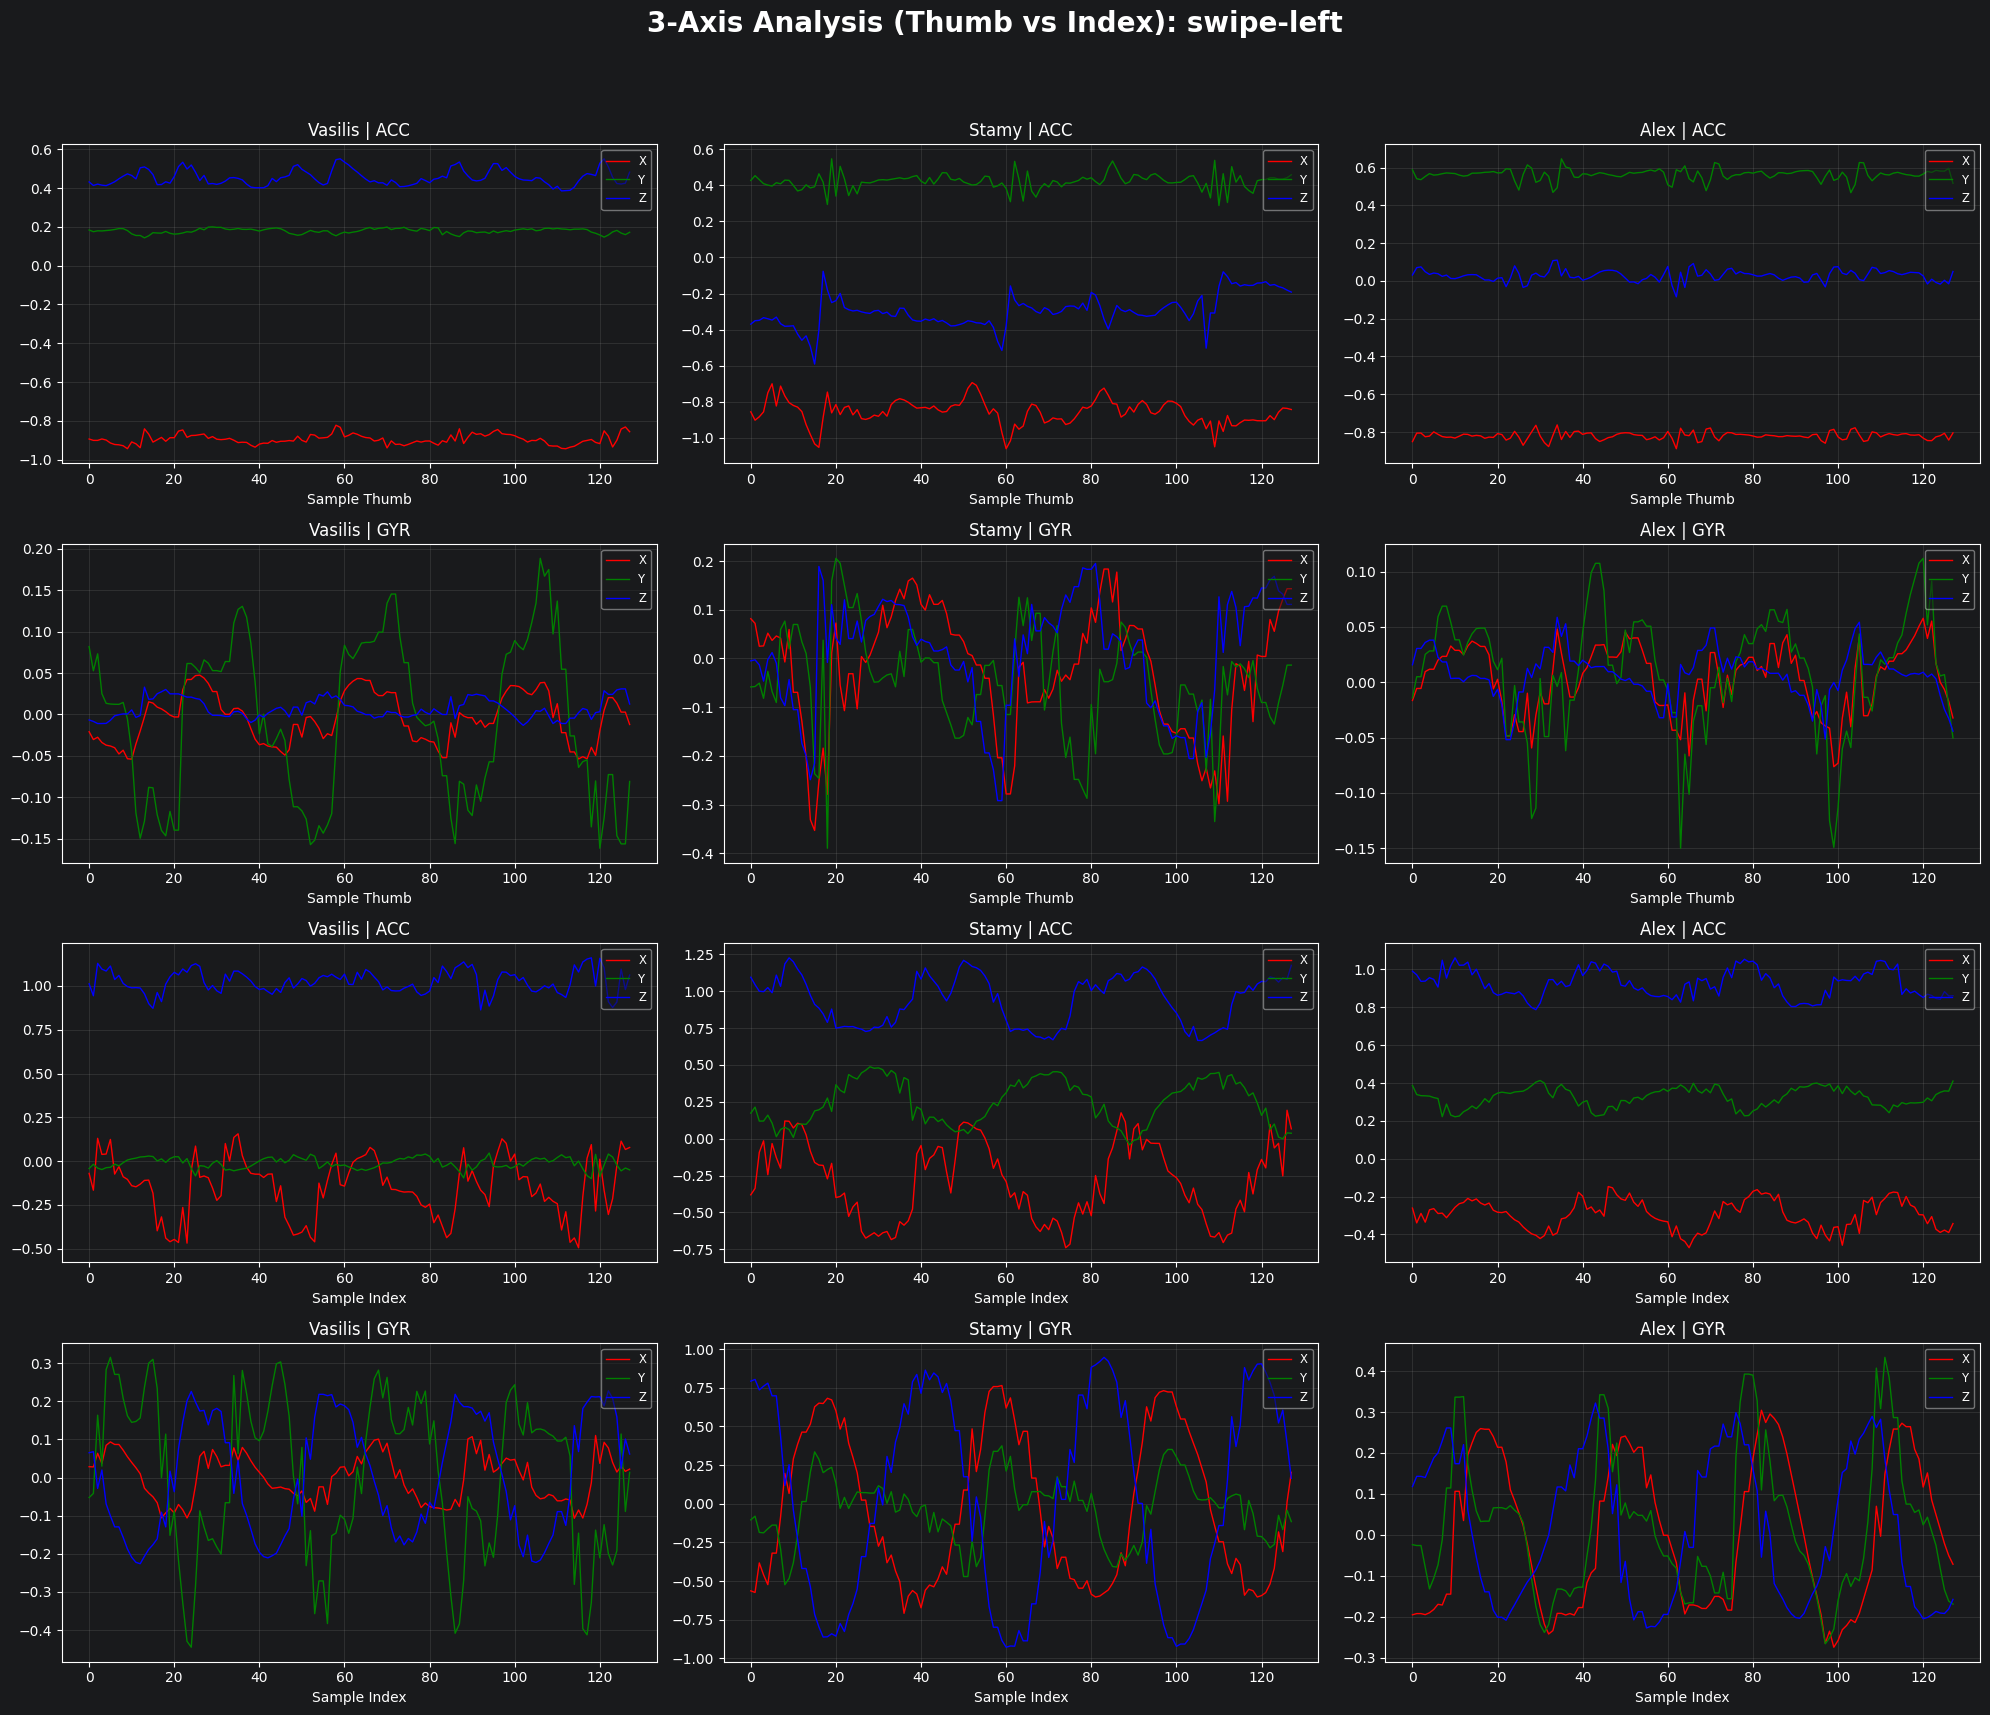

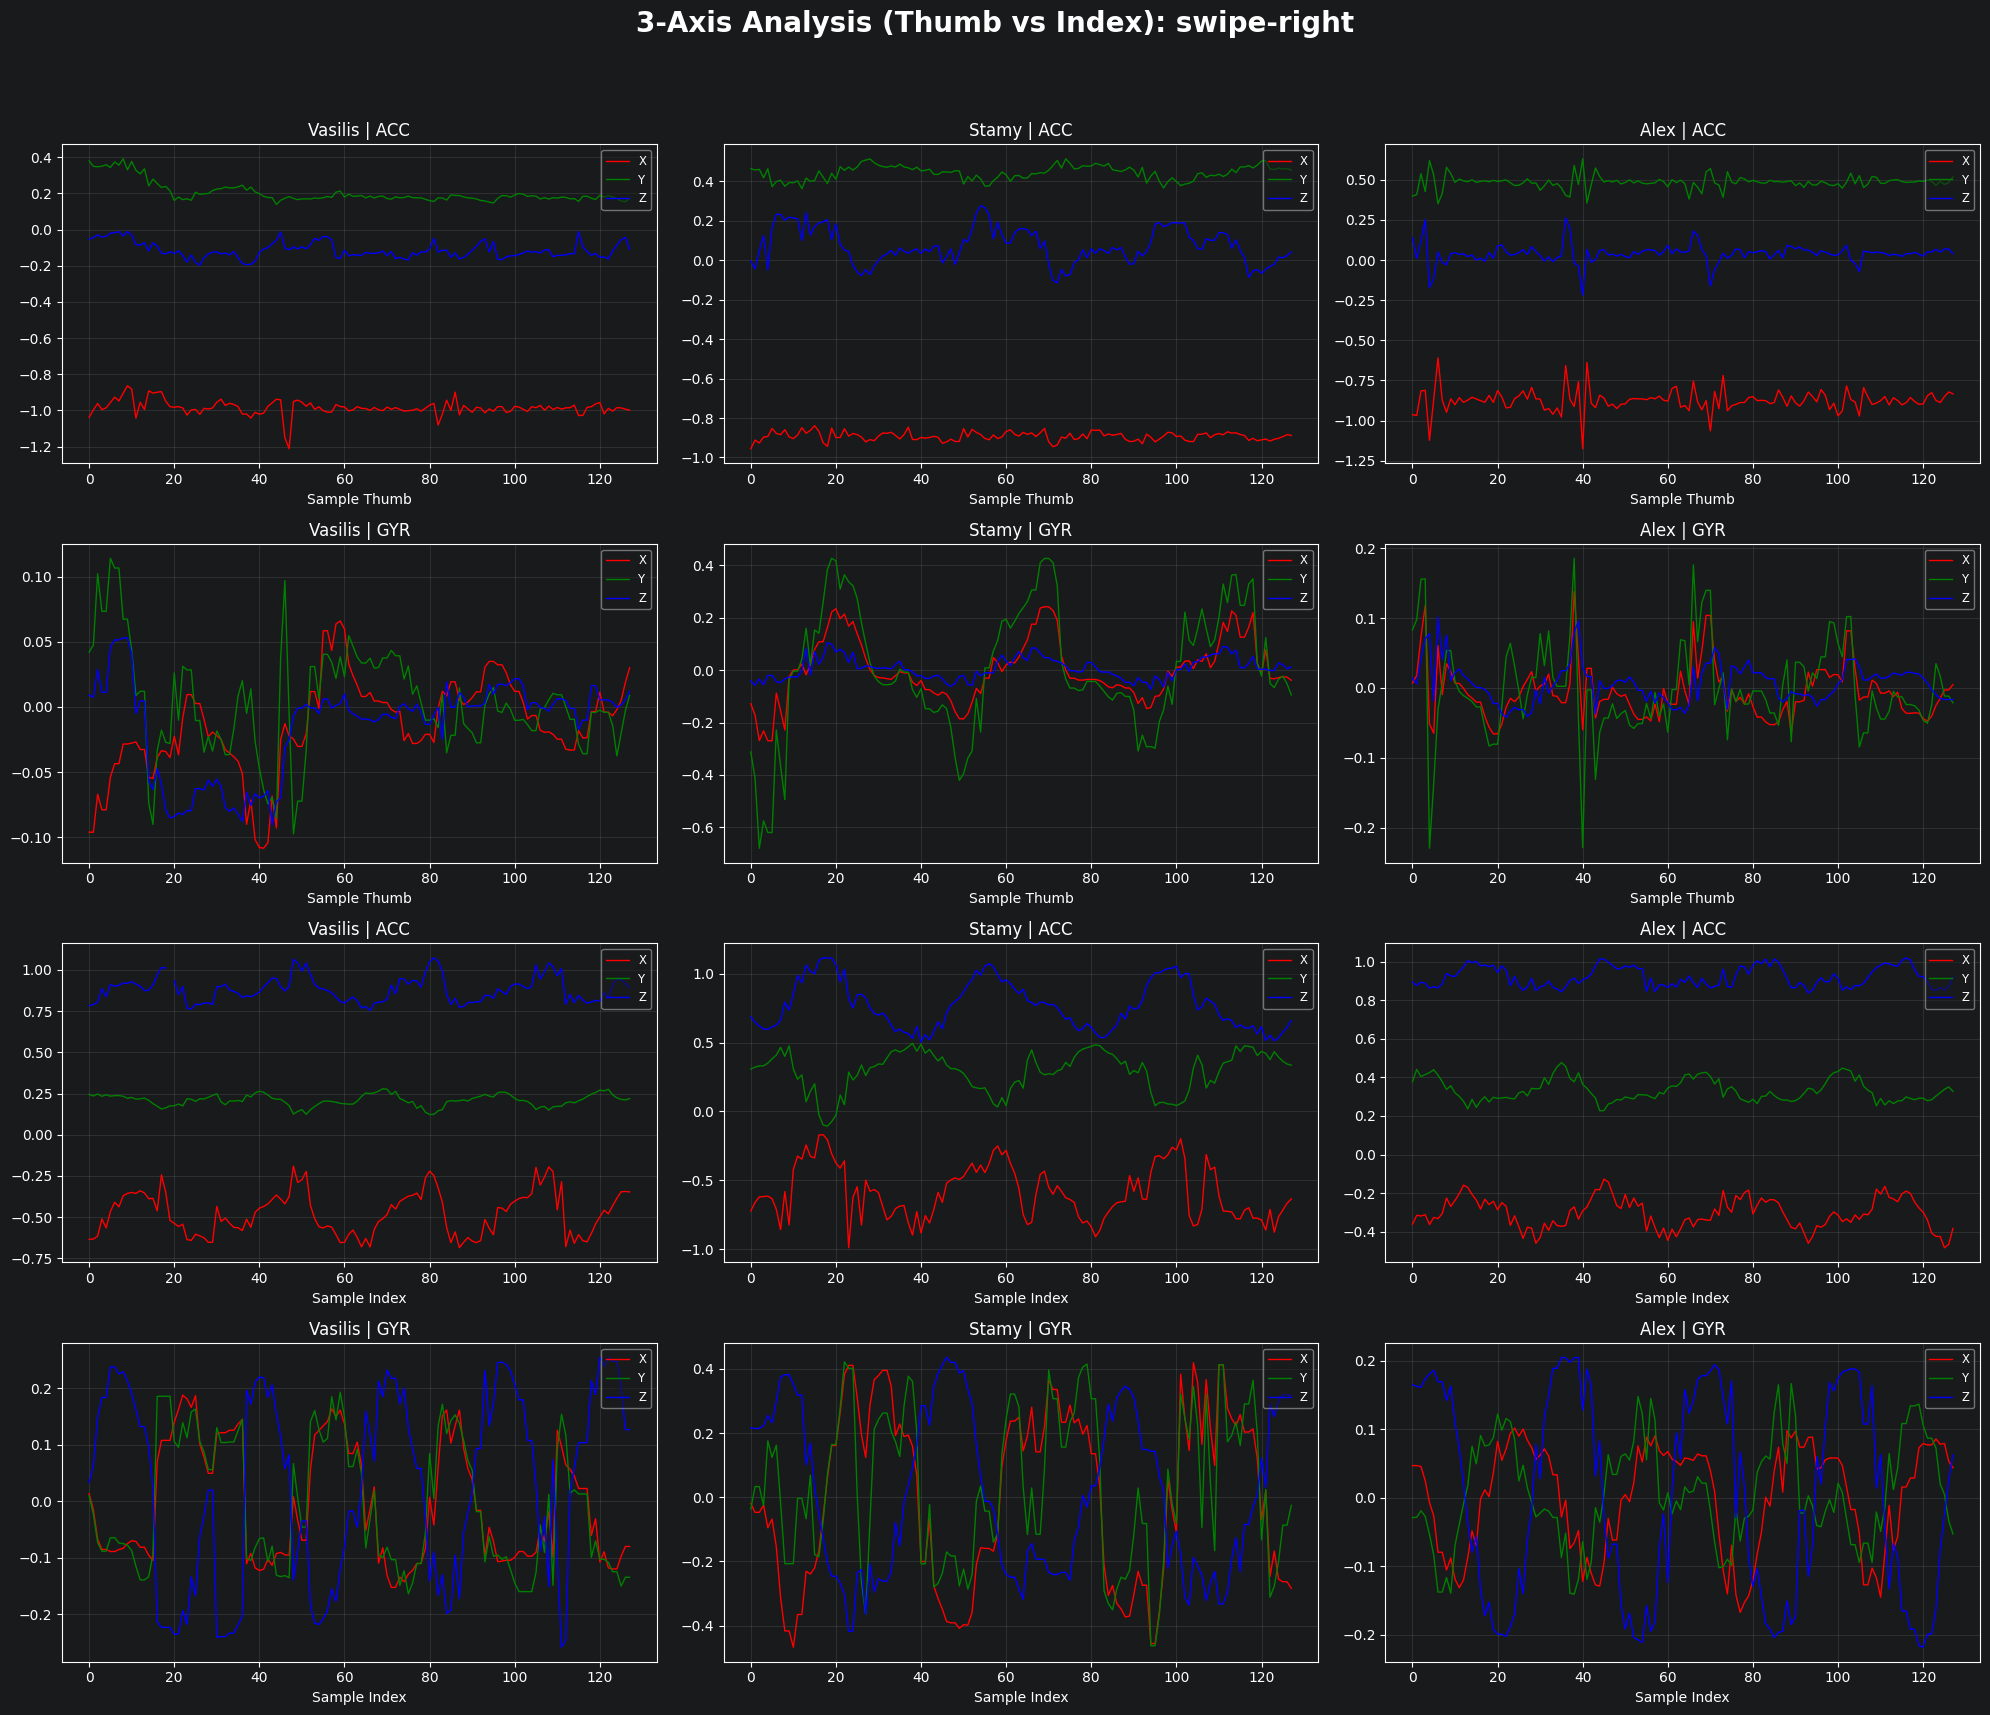

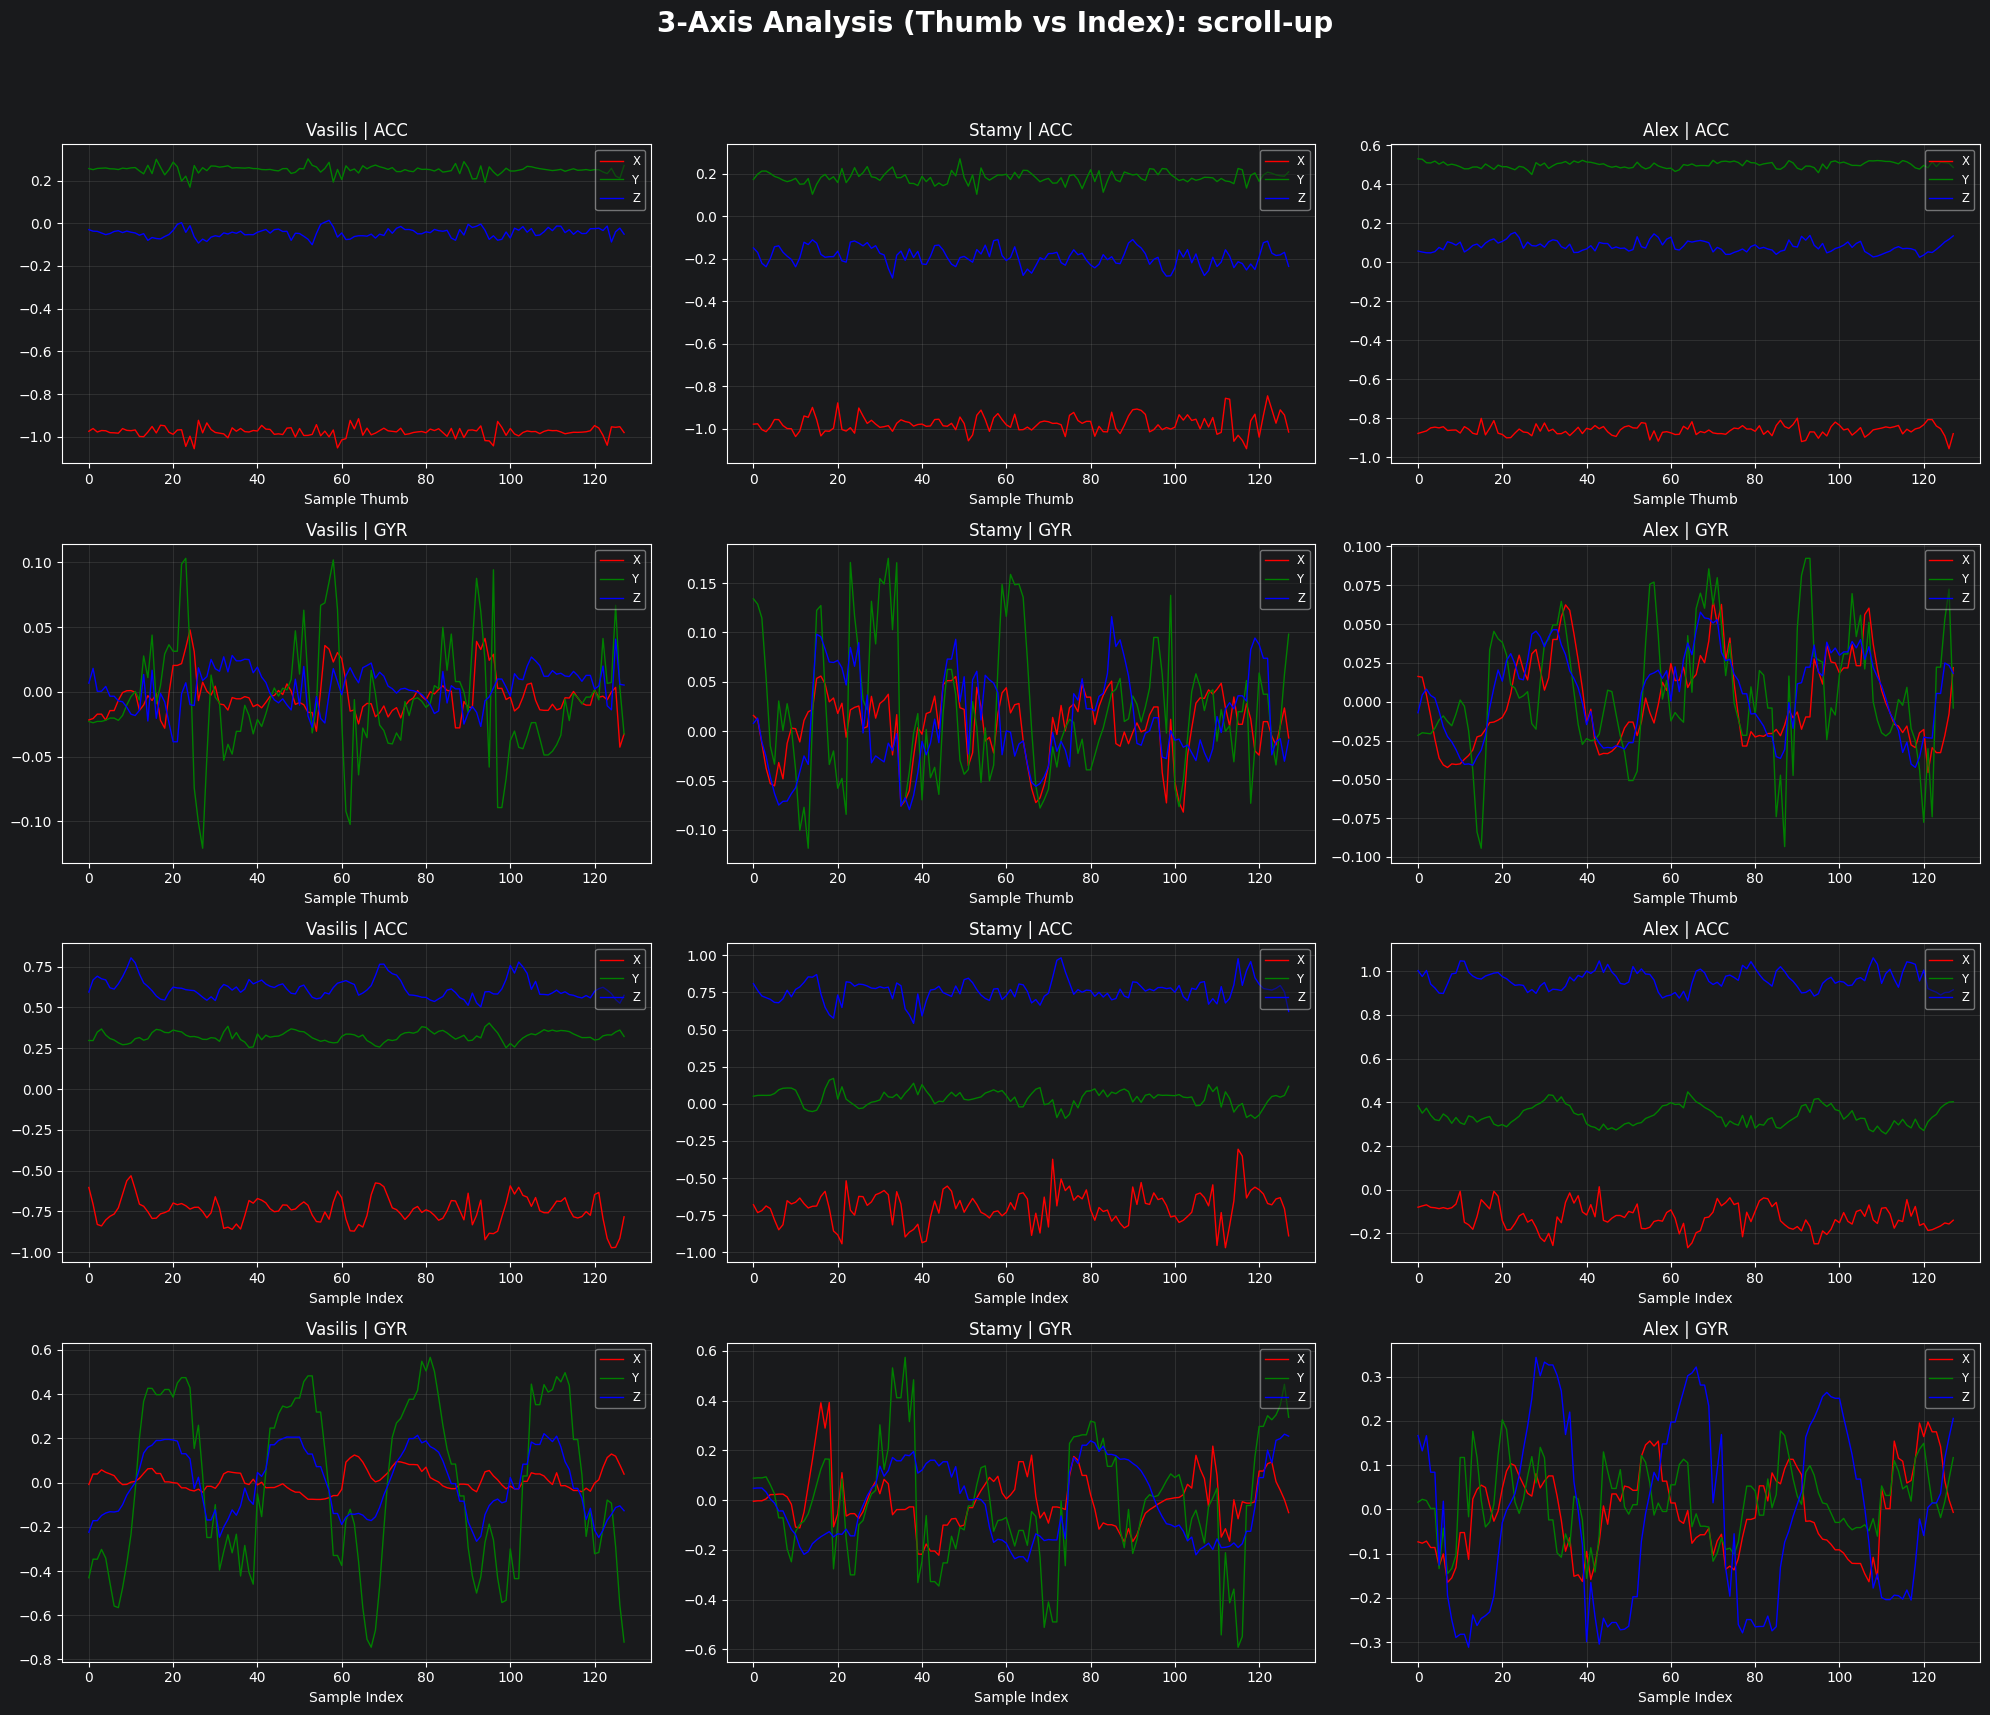

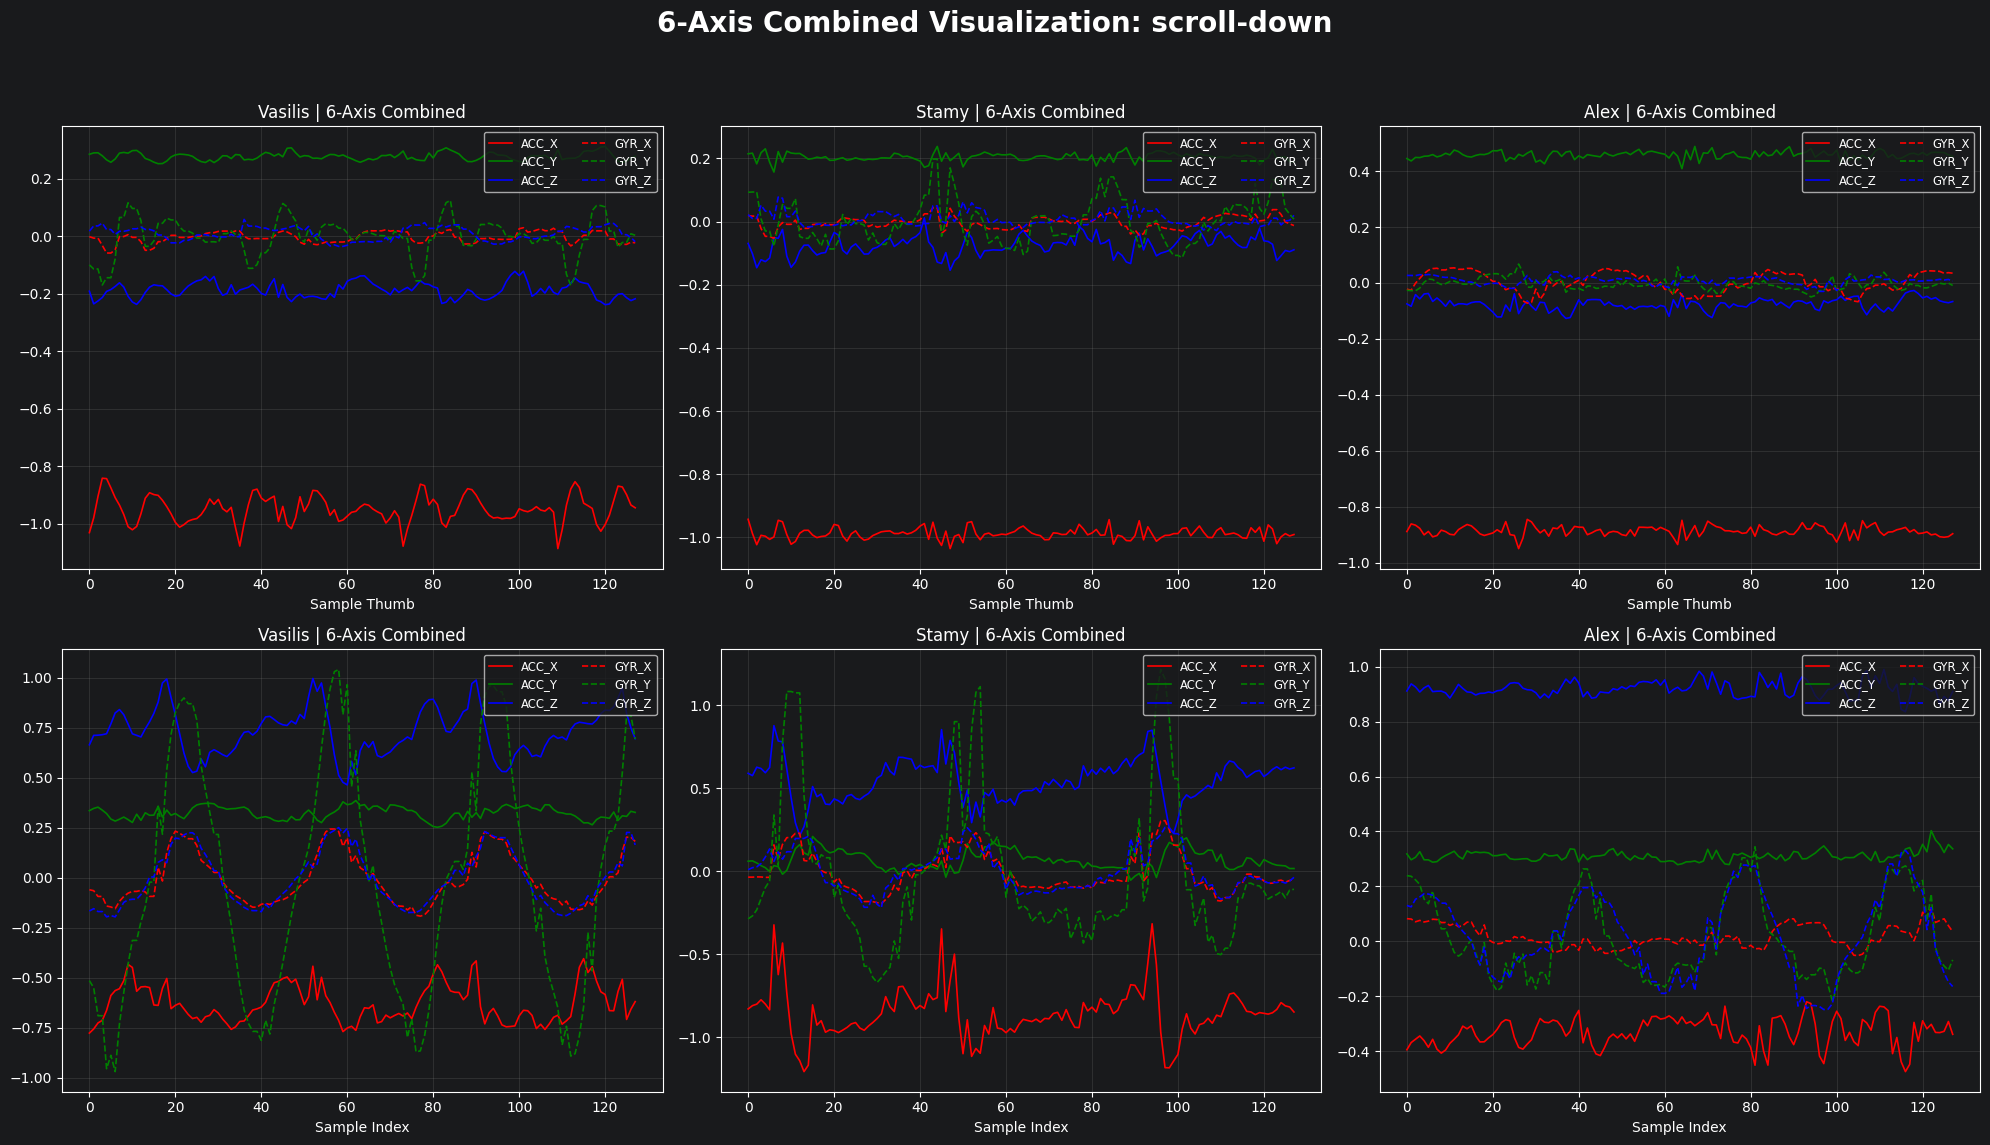

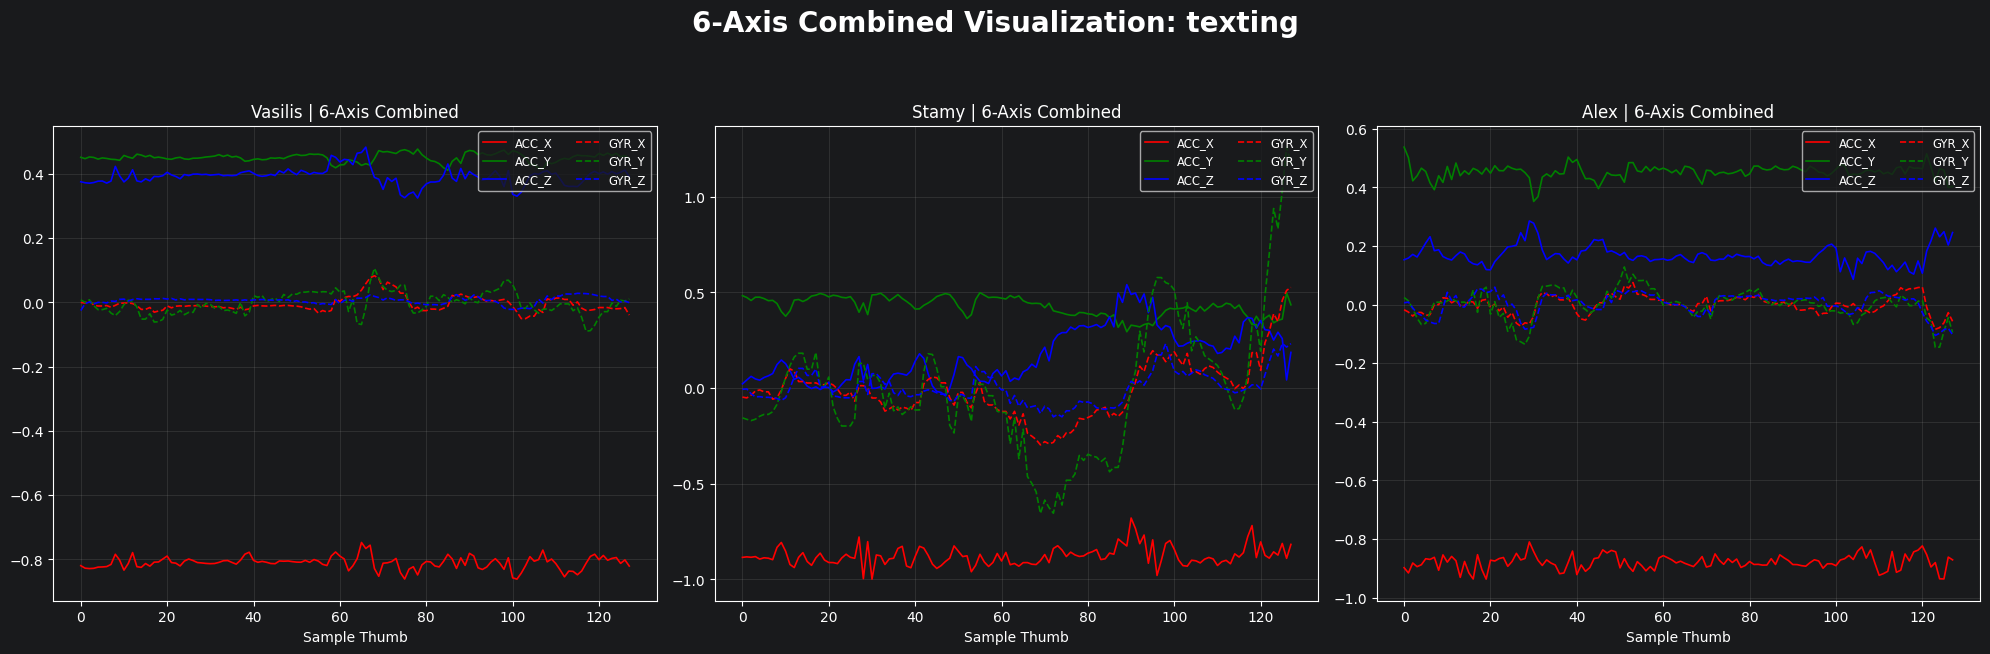

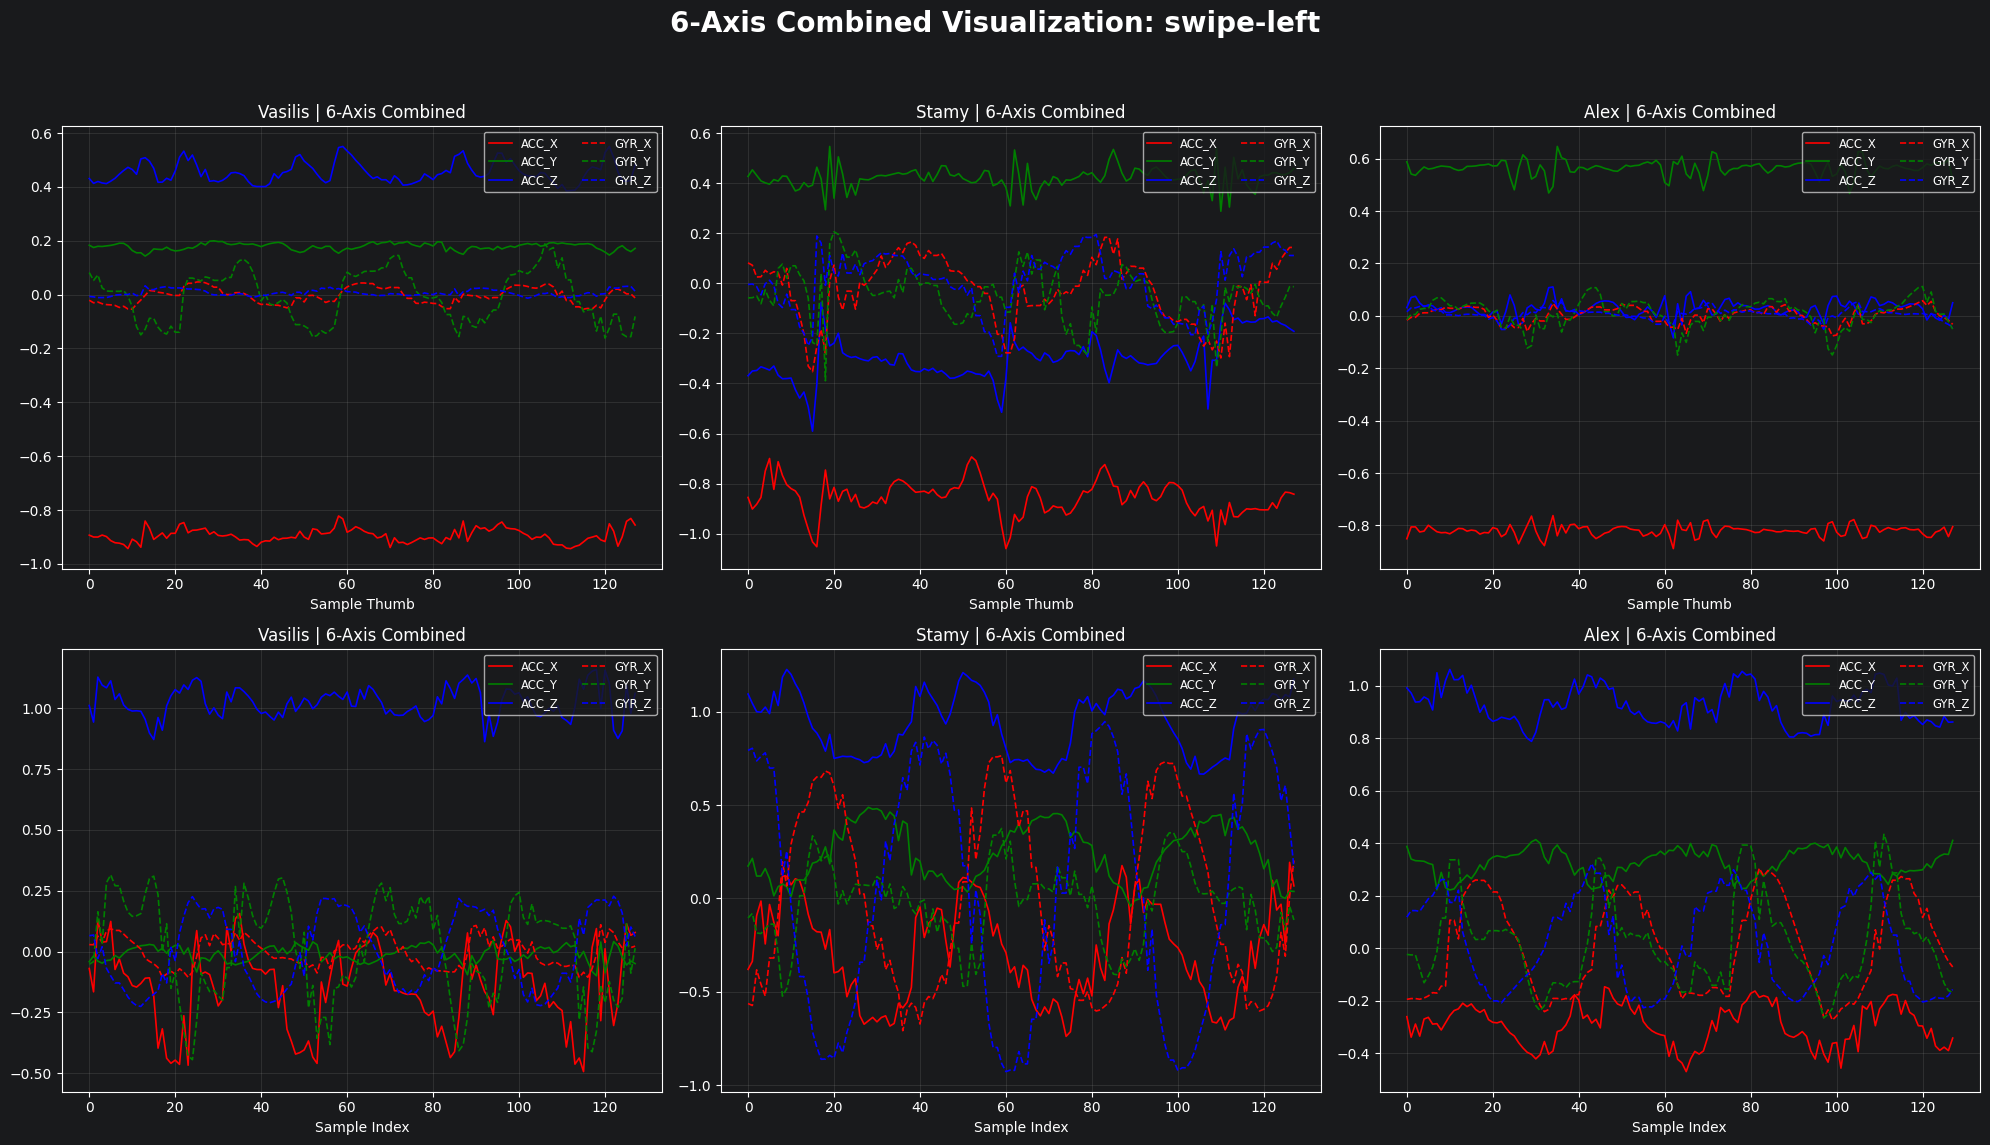

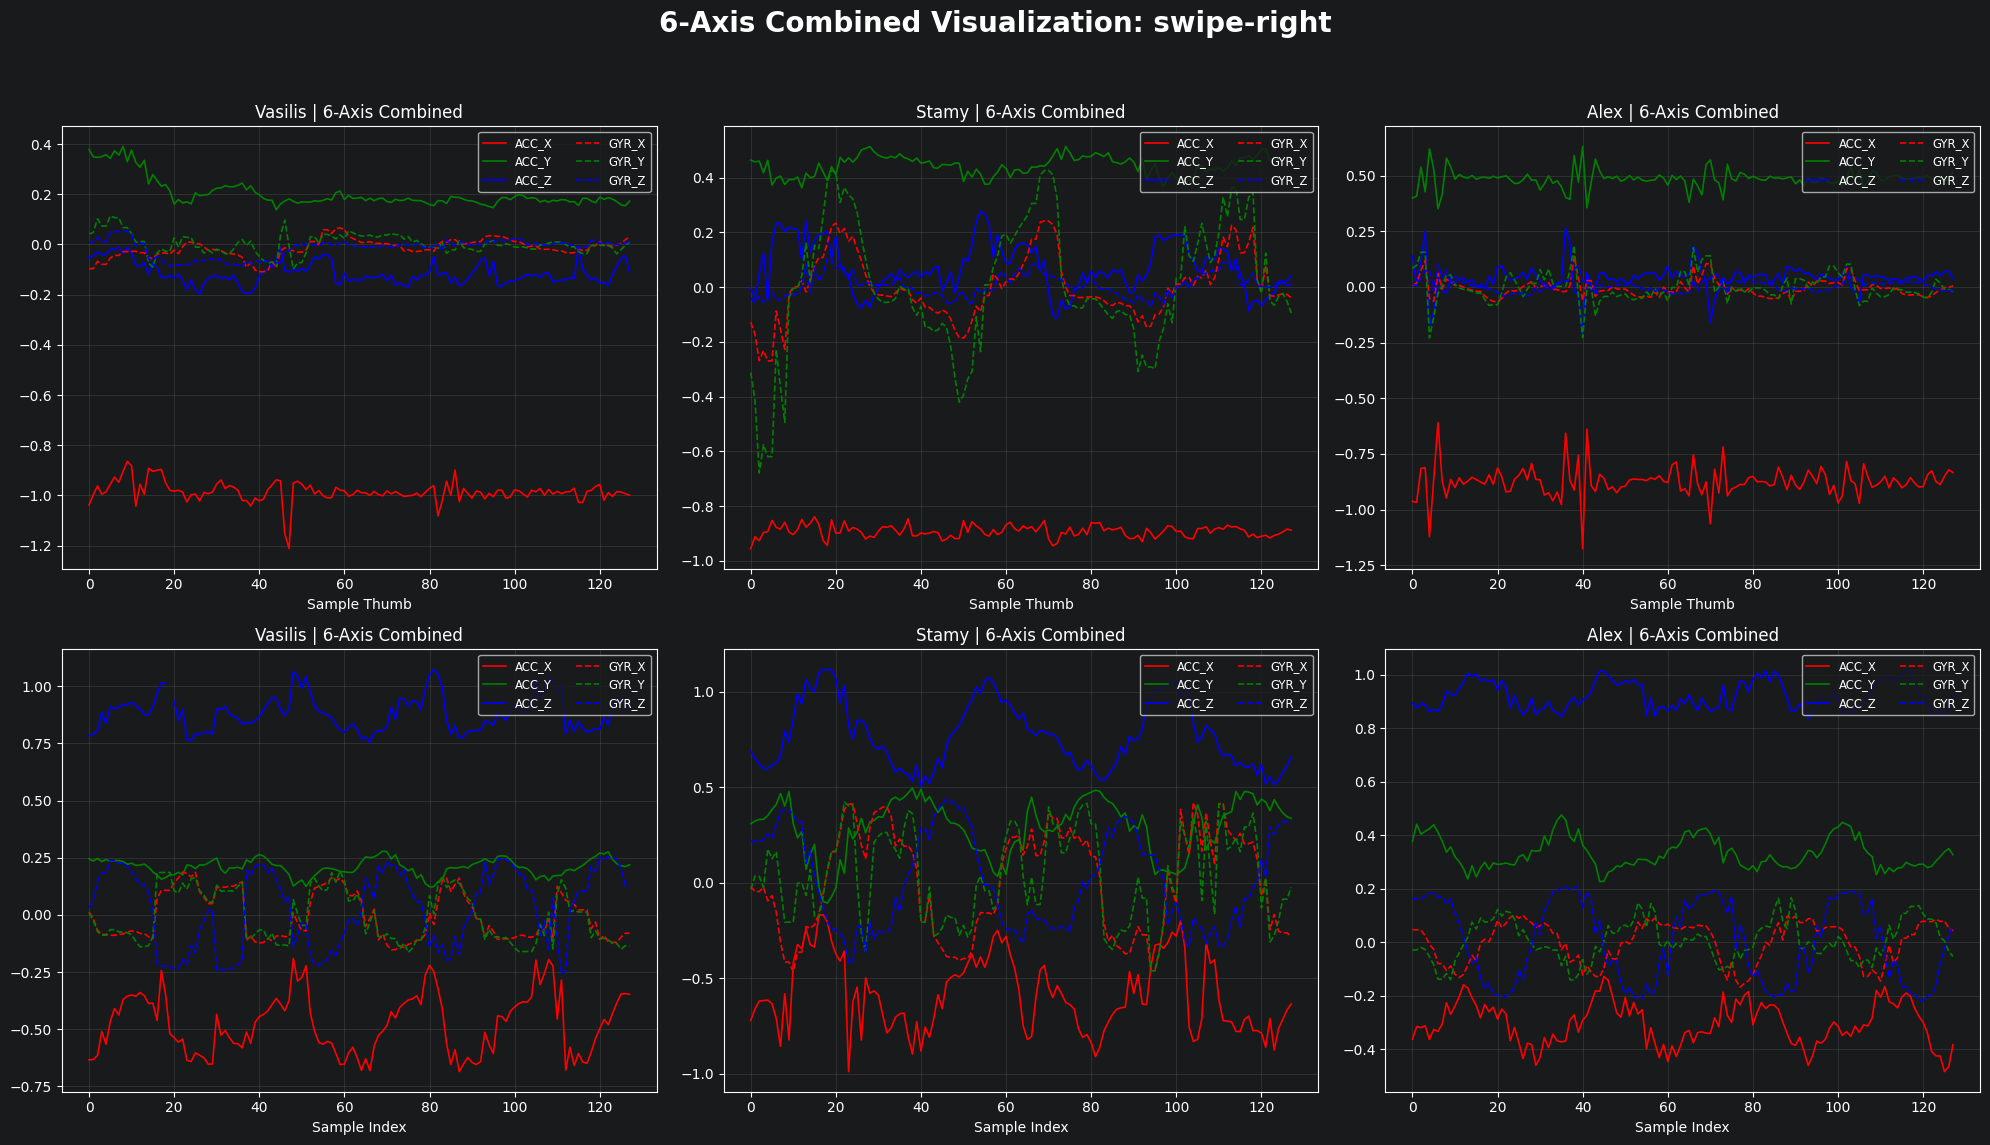

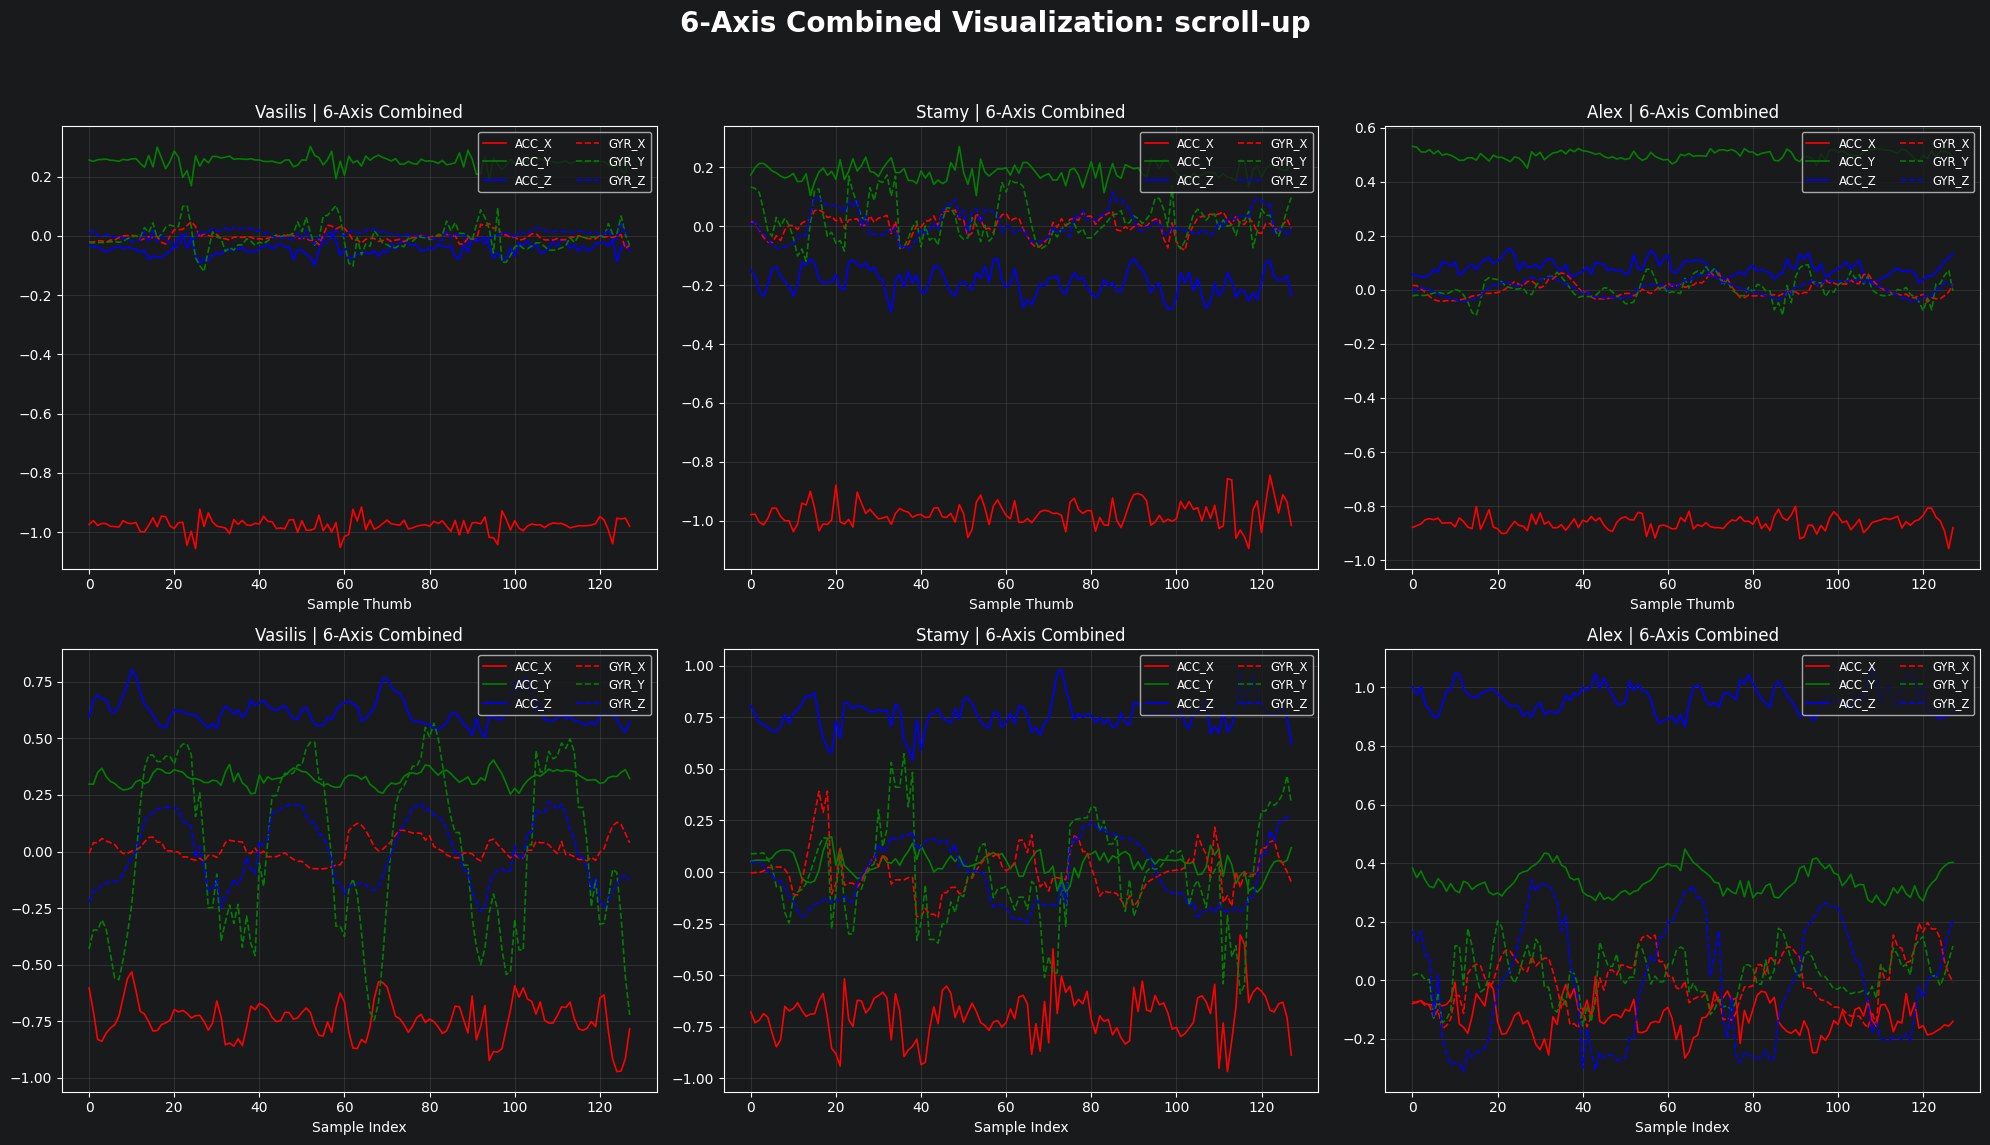

In [4]:
all_users = load_data_for_visualization(pairs)

Plot_3axis(all_users, out_dir=FIGURES_DIR)
Plot_6axis(all_users, out_dir=FIGURES_DIR)

## 3. Load + Merge + Filter

Τρία βήματα ανά session:

### Loading με monotonic-epoch fix
Οι helpers `load_acc_csv` και `load_gyr_csv` ξαναγράφουν τα Epoch timestamps όταν εμφανίζονται duplicates (περίπου το 25% των rows έχει το ίδιο millisecond): κάθε duplicate σπρώχνεται στο `last + 1 ms`. Η σωρευμένη απόκλιση παραμένει πολύ κάτω από το tolerance των 10 ms του join, οπότε δεν χάνουμε samples ούτε σπάμε την acc - gyr alignment.

### Tolerance-based join
Η `merge_acc_gyr` χρησιμοποιεί `pd.merge_asof(direction="nearest", tolerance_ms=10)` αντί για exact join. Αυτό απαντά στο πρόβλημα ότι τα δύο sensor streams έχουν ελαφρώς διαφορετικά timestamps παρόλο που και τα δύο μεταδίδουν στα 100 Hz.

### Lowpass filtering: Butterworth
Παράμετροι από το `config.yml`: order = 4, normalized cutoff `Wn = 0.2` (δηλαδή `fc = 10 Hz @ fs = 100 Hz`). Επιλέξαμε Butterworth γιατί:
- **Maximally flat passband** - δεν εισάγει ripple (σε αντίθεση με Chebyshev / Elliptic).
- **Smooth, monotonic roll-off**.
- Είναι το go-to default για biosignal και IMU processing.

Magnitude response:
$$
|H(f)|^2 \;=\; \frac{1}{1 + (f / f_c)^{2N}}
$$

όπου $f_c$ είναι η cutoff frequency και $N$ η τάξη του φίλτρου.

Με `N = 4` (τάξης 4), η απόσβεση στο stopband είναι αρκετή για να αφαιρεθεί ο ηλεκτρονικός θόρυβος υψηλών συχνοτήτων χωρίς να χαθεί η motion information (HAR signals τυπικά < 10 Hz). Χρησιμοποιούμε **zero-phase** φιλτράρισμα μέσω `sosfiltfilt` ώστε να μην εισάγεται phase distortion.

Το αποτέλεσμα είναι ένα cleaned 6-axis DataFrame ανά session.


In [5]:
sessions = []
for meta, acc, gyr in pairs:
    merged = merge_acc_gyr(load_acc_csv(acc), load_gyr_csv(gyr))
    df = apply_continuous_filter(merged, order=FILTER_ORDER, wn=FILTER_WN)
    meta = {**meta, "acc_csv": acc.stem, "gyr_csv": gyr.stem}
    sessions.append((df, meta))
print(f"Loaded {len(sessions)} merged sessions")

# Quick sanity on the first filtered dataframe
df0, meta0 = sessions[0]
print(f"First session: {meta0['gesture_id']} / {meta0['finger']} / user={meta0['user']}  shape={df0.shape}")
df0.head()

Loaded 27 merged sessions
First session: scroll-down / index / user=a  shape=(15147, 7)


,Epoch,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
0,1777373011388,-0.377528,0.314248,0.919623,0.079780,0.236762,0.134219
1,1777373011389,-0.369795,0.311139,0.922056,0.078528,0.230457,0.141400
2,1777373011390,-0.364643,0.307445,0.923365,0.077437,0.220188,0.150110
3,1777373011391,-0.363657,0.303603,0.923099,0.076570,0.205229,0.158791
4,1777373011418,-0.367179,0.300258,0.921179,0.075803,0.185042,0.165558


## 4. Insert into MongoDB

### Γιατί MongoDB και όχι flat files
Στον AIoT lifecycle, το data storage layer είναι θεμελιώδες. Επιλέξαμε document-oriented database γιατί:
- Κάθε session είναι ένα self-contained document με metadata + 6-axis time-series array - φυσική αντιστοιχία με JSON-like structure.
- Το query ανά user, gesture ή finger / typing style γίνεται απλό με indexed fields.
- Εύκολη ενσωμάτωση με downstream Python (pymongo) και πιθανές λύσεις real-time streaming στο μέλλον.

### Idempotent re-run
Η `mongo_connect(reset=True)` κάνει `delete_many({})` στην collection πριν την εισαγωγή. Δημιουργείται unique index στο `session_id` (24-character hex, παράγεται από `secrets.token_hex(12)` στο `build_document`) ώστε διπλές εισαγωγές να αποτυγχάνουν explicit, αντί να δημιουργούν silent duplicates.

### Document schema
Κάθε document περιέχει:
- `session_id` (PK)
- `data`: dict με 6 lists `{acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z}` (filtered samples)
- Metadata: `gesture_id`, `finger`, `typing_style`, `hand`, `sr`, `sensor`, `primary`, `spontaneous`, `user`, `datetime`

Σύνολο: **27 documents** (9 συνδυασμοί gesture × variant × 3 users).


In [6]:
coll = mongo_connect(uri=config["client"], db=config["db"], collection=config["col"], reset=config["reset_collection"])
print(f"Connected to {coll.full_name}")

docs = (build_document(df, meta) for df, meta in sessions)
n_ins = insert_documents(coll, docs)
print(f"Inserted {n_ins} documents")

Connected to IoTSocial.sensor_data
Inserted 27 documents


## 5. Verification

Sanity check ότι τα stored data ταυτίζονται με αυτά που εισήχθησαν: `coll.count_documents({}) == len(sessions)`. Είναι το ισοδύναμο του βήματος *"Verify assumptions if possible"*. Αν αυτό το assertion αποτύχει, κάτι πήγε στραβά (πιθανές αιτίες: collisions στο `session_id`, network glitch κατά την εισαγωγή, OOM στη MongoDB).

Η ανάλυση ανά gesture επιβεβαιώνει τη σύνθεση του dataset: τέσσερις directional χειρονομίες (`scroll-down`, `scroll-up`, `swipe-left`, `swipe-right`) με 6 documents η καθεμία (2 variants × 3 users), και η χειρονομία `texting` με 3 documents (1 variant × 3 users) - σύνολο 27.

Μετά από αυτό, η collection είναι έτοιμη να καταναλωθεί από το επόμενο στάδιο του pipeline (segmentation notebook → segmented.pkl → feature engineering / time-series modeling notebooks).


In [7]:
assert coll.count_documents({}) == len(sessions), "Document count mismatch"

# Count per gesture
from collections import Counter
gestures = Counter(d["gesture_id"] for d in coll.find({}, {"gesture_id": 1}))
print("Per gesture:", dict(gestures))

# Inspect one document in MongoDB (without the heavy `data` field)
sample = coll.find_one({}, {"data": 0})
sample

Per gesture: {'scroll-down': 6, 'scroll-up': 6, 'swipe-left': 6, 'swipe-right': 6, 'texting': 3}


{'_id': ObjectId('6a0de633137e3d7d219a71df'),
 'session_id': 'd0c4c1ffbe3c84a584953381',
 'gesture_id': 'scroll-down',
 'finger': 'index',
 'typing_style': 'na',
 'hand': 0,
 'sr': 100,
 'sensor': 'AccGyr',
 'primary': 0,
 'spontaneous': 0,
 'user': 'a',
 'datetime': datetime.datetime(2026, 5, 20, 16, 49, 55, 968000)}